# Imports dependencies

In [76]:
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss, recall_score, precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

import tensorflow as tf
import tensorflow_decision_forests as tfdf

print(f"Found TF-DF {tfdf.__version__}")

Found TF-DF 1.2.0


# Load dataset

In [155]:
train_data = pd.read_csv("/kaggle/input/titanic/train.csv")
train_data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [142]:
print("=== 基本统计信息（describe） ===")
display(train_data.describe().round(2))

=== 基本统计信息（describe） ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


# Prepare dataset

名字标准化和提取ticket的前缀


In [156]:
def preprocess(df):
    df = df.copy()
    
    def normalize_name(x):
        return " ".join([v.strip(",()[].\"'") for v in x.split(" ")])
    
    def ticket_number(x):
        if x.isdigit():
            return int(x.split(" ")[-1])
        else:
            return 0
        
    def ticket_item(x):
        items = x.split(" ")
        if len(items) == 1:
            return "NONE"
        return "_".join(items[0:-1])
    
    df["Name"] = df["Name"].apply(normalize_name)
    df["Ticket_number"] = df["Ticket"].apply(ticket_number)
    df["Ticket_item"] = df["Ticket"].apply(ticket_item)                     
    return df
    
preprocessed_train_df = preprocess(train_data)

preprocessed_train_df.head(5)
preprocessed_train_df.dtypes

PassengerId        int64
Survived           int64
Pclass             int64
Name              object
Sex               object
Age              float64
SibSp              int64
Parch              int64
Ticket            object
Fare             float64
Cabin             object
Embarked          object
Ticket_number      int64
Ticket_item       object
dtype: object

In [157]:
# convert type
cat_cols = preprocessed_train_df.select_dtypes(exclude=['int64', 'float64']).columns

preprocessed_train_df[cat_cols] = preprocessed_train_df[cat_cols].astype(str)
preprocessed_train_df.dtypes

PassengerId        int64
Survived           int64
Pclass             int64
Name              object
Sex               object
Age              float64
SibSp              int64
Parch              int64
Ticket            object
Fare             float64
Cabin             object
Embarked          object
Ticket_number      int64
Ticket_item       object
dtype: object

In [158]:

numeric_cols = preprocessed_train_df.select_dtypes(include=['int64', 'float64']).columns.to_list()
numeric_cols

['PassengerId',
 'Survived',
 'Pclass',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'Ticket_number']

In [149]:

cat_cols = preprocessed_train_df.select_dtypes(exclude=['int64', 'float64']).columns.to_list()
cat_cols

['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked', 'Ticket_item']

# 剔除增加噪音的features和label.

hash_cat_cols ['Name_hash', 'Sex_hash', 'Ticket_hash', 'Cabin_hash', 'Embarked_hash', 'Ticket_item_hash']


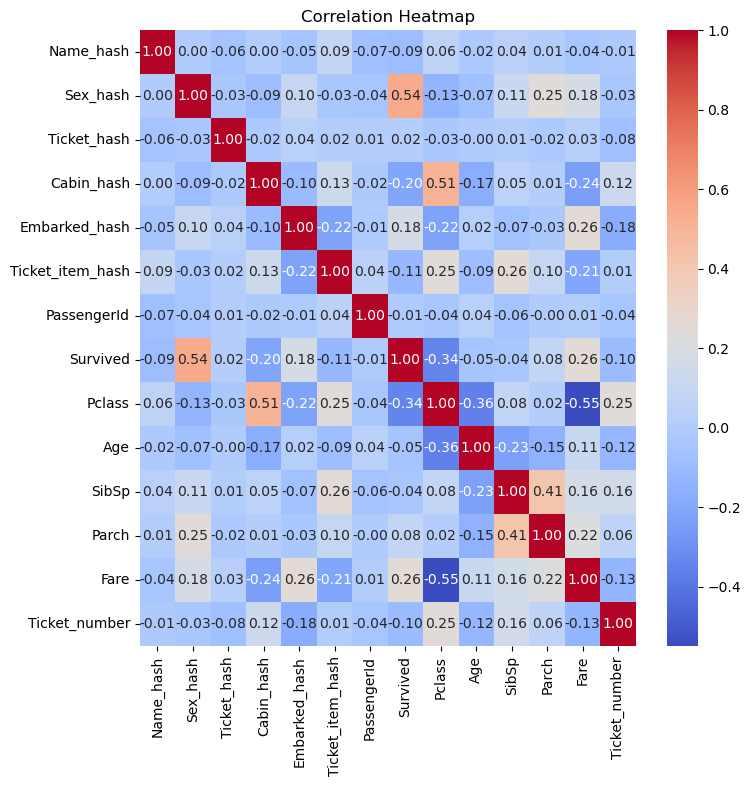

In [159]:
# hash encode cat feature
hash_cat_cols = [col + '_hash' for col in cat_cols]
print('hash_cat_cols', hash_cat_cols)

for feature_name in cat_cols:
    if 'Sex' == feature_name:
        preprocessed_train_df[feature_name + '_hash'] = preprocessed_train_df[feature_name].apply(lambda x: hash(x) % 5)
    else:
        preprocessed_train_df[feature_name + '_hash'] = preprocessed_train_df[feature_name].apply(lambda x: hash(x) % 200) # set to 200 category


# handle numeric value missing
preprocessed_train_df['Age'] = preprocessed_train_df['Age'].fillna(preprocessed_train_df['Age'].sum()/ len(preprocessed_train_df['Age']))
preprocessed_train_df[numeric_cols] = preprocessed_train_df[numeric_cols].fillna(0)


# heatmap corr
draw_d = preprocessed_train_df[hash_cat_cols+numeric_cols]
preprocessed_train_df[preprocessed_train_df.columns]

corr_matrix = draw_d.corr()
plt.figure(figsize=(8, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.xticks(np.arange(len(corr_matrix.columns)) + 0.5, corr_matrix.columns)
plt.yticks(np.arange(len(corr_matrix.columns)) + 0.5, corr_matrix.columns)
plt.title('Correlation Heatmap')
plt.show()


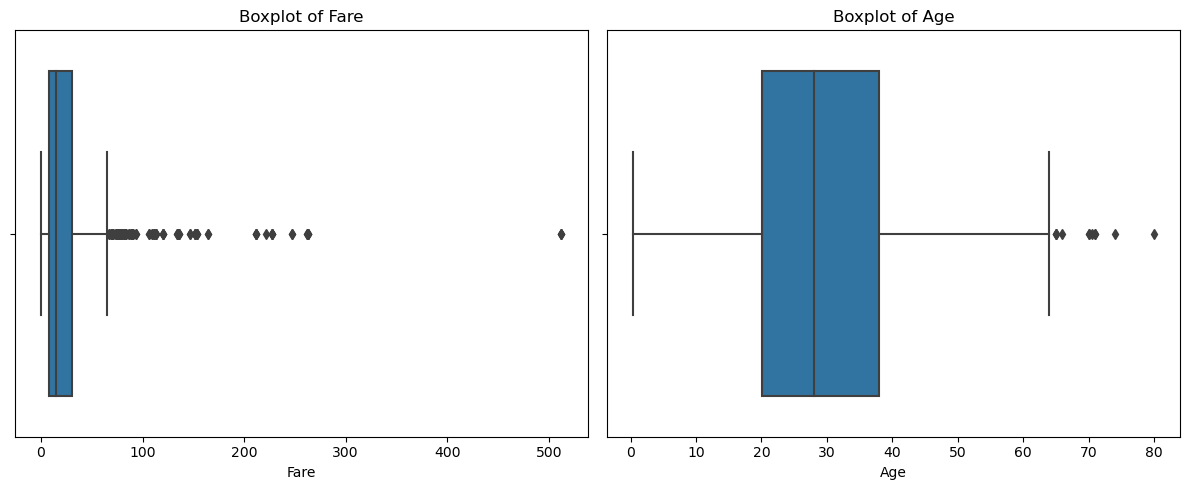

Fare 异常值数量: 116
Age 异常值数量: 11


In [160]:

# 绘制 Fare 和 Age 的箱线图，初步观察异常值
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=train_data['Fare'])
plt.title("Boxplot of Fare")

plt.subplot(1, 2, 2)
sns.boxplot(x=train_data['Age'])
plt.title("Boxplot of Age")

plt.tight_layout()
plt.show()

# 使用 IQR 方法识别异常值
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# 检测 Fare 和 Age 的异常值
fare_outliers, fare_lb, fare_ub = detect_outliers_iqr(train_data, 'Fare')
age_outliers, age_lb, age_ub = detect_outliers_iqr(train_data, 'Age')

print(f"Fare 异常值数量: {fare_outliers.shape[0]}")
print(f"Age 异常值数量: {age_outliers.shape[0]}")



In [152]:
preprocessed_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PassengerId       891 non-null    int64  
 1   Survived          891 non-null    int64  
 2   Pclass            891 non-null    int64  
 3   Name              891 non-null    object 
 4   Sex               891 non-null    object 
 5   Age               714 non-null    float64
 6   SibSp             891 non-null    int64  
 7   Parch             891 non-null    int64  
 8   Ticket            891 non-null    object 
 9   Fare              891 non-null    float64
 10  Cabin             891 non-null    object 
 11  Embarked          891 non-null    object 
 12  Ticket_number     891 non-null    int64  
 13  Ticket_item       891 non-null    object 
 14  Name_hash         891 non-null    int64  
 15  Sex_hash          891 non-null    int64  
 16  Ticket_hash       891 non-null    int64  
 1

In [168]:

label = 'Survived'
# numeric_cols.remove(label)
numeric_cols

['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Ticket_number']

In [170]:
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import train_test_split

X=preprocessed_train_df[hash_cat_cols + numeric_cols]
y = preprocessed_train_df[label]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.columns)
print(X_test.shape, X_train.shape)

Index(['Name_hash', 'Sex_hash', 'Ticket_hash', 'Cabin_hash', 'Embarked_hash',
       'Ticket_item_hash', 'PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch',
       'Fare', 'Ticket_number'],
      dtype='object')
(179, 13) (712, 13)


In [196]:
from sklearn.metrics import precision_recall_curve, average_precision_score, auc

def draw_pr_auc(y_test, pred_proba):
    precision, recall, thresholds = precision_recall_curve(y_test, pred_proba)
    pr_auc = auc(recall, precision)
    
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.grid()
    plt.show()
    
    print(f"PR AUC: {pr_auc:.4f}")
    print(f"Average Precision Score: {average_precision_score(y_test, xgb_pred_proba):.4f}")


# Logistic Regression

In [209]:

# 初始化并训练逻辑回归模型
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# 预测概率和标签
lr_pred_prob = lr_model.predict_proba(X_test)[:, 1]
lr_pred_label = lr_model.predict(X_test)

# 计算评估指标
lr_acc = accuracy_score(y_test, lr_pred_label)
lr_recall = recall_score(y_test, lr_pred_label)
lr_precision = precision_score(y_test, lr_pred_label)

# 输出结果
print(f"Logistic Regression Accuracy:  {lr_acc:.4f}")
print(f"Logistic Regression Recall:    {lr_recall:.4f}")
print(f"Logistic Regression Precision: {lr_precision:.4f}")

Logistic Regression Accuracy:  0.6536
Logistic Regression Recall:    0.3243
Logistic Regression Precision: 0.6667


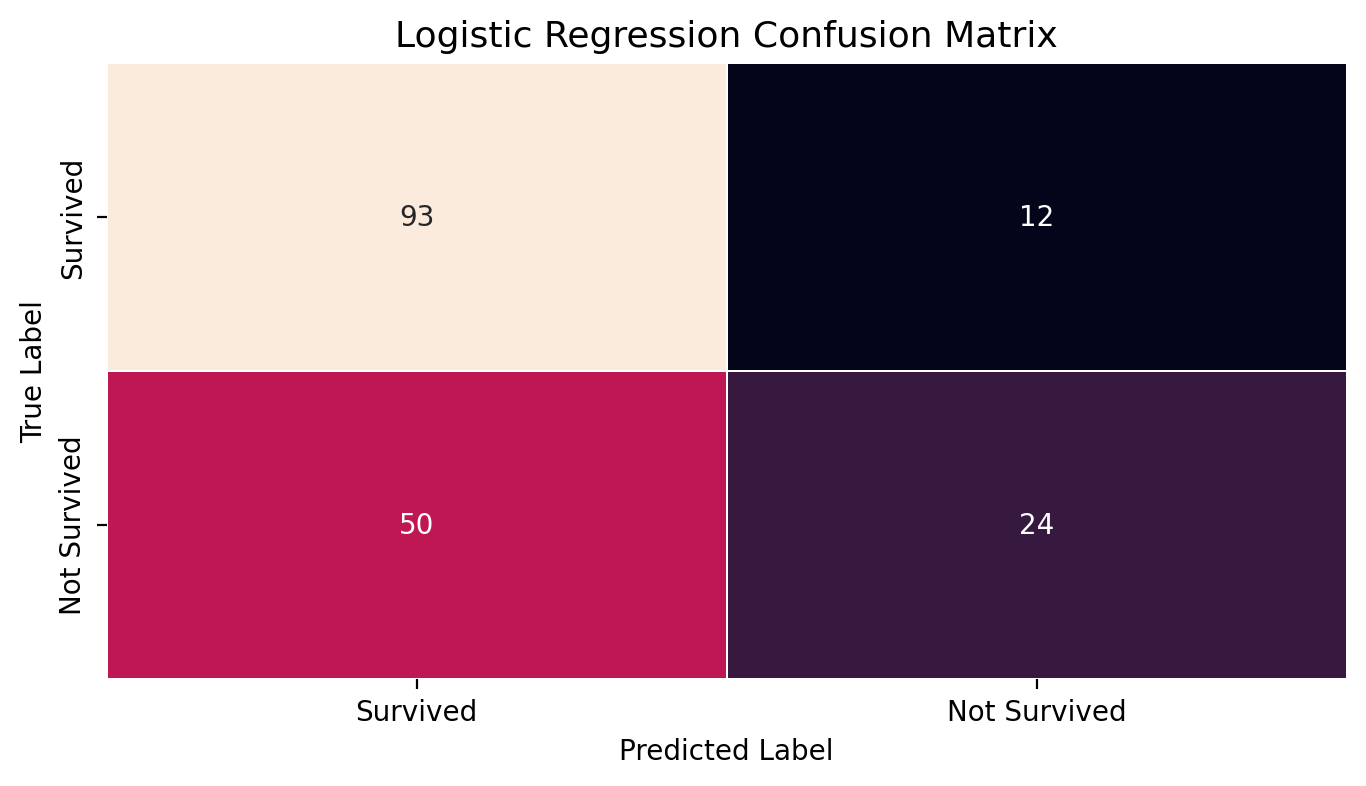

In [179]:
#混淆矩阵
confusion_mtx = confusion_matrix(y_test,lr_pred_label)
f,ax = plt.subplots(figsize = (8,4),dpi=200)
sns.heatmap(confusion_mtx, annot=True, linewidths=0.1, fmt='.0f', ax=ax,cbar=False,
xticklabels=label_name, yticklabels=label_name)

plt.xlabel("Predicted Label",fontsize=10)
plt.ylabel("True Label",fontsize=10)
plt.title("Logistic Regression Confusion Matrix",fontsize=13)
plt.show()


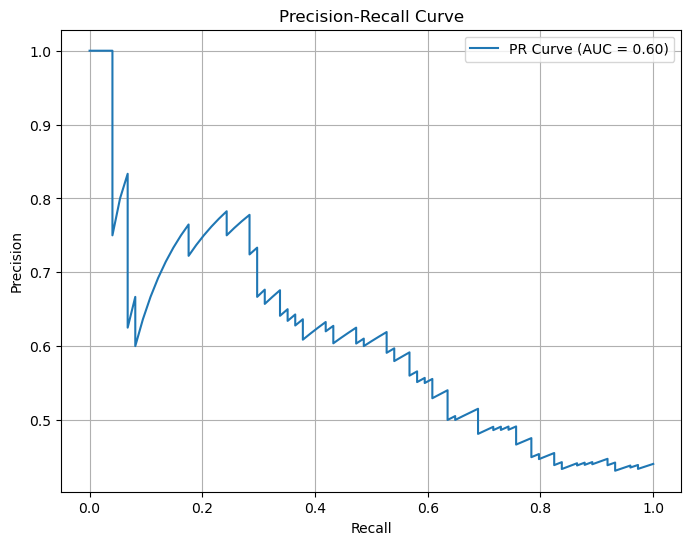

PR AUC: 0.6022
Average Precision Score: 0.7903


In [210]:
draw_pr_auc(y_test,lr_pred_prob)

# Random forest

In [207]:

# 初始化并训练随机森林模型
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 预测
rf_y_pred_prob = rf_model.predict_proba(X_test)[:, 1]
rf_y_pred_label = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_y_pred_label)
rf_recall = recall_score(y_test, rf_y_pred_label)
rf_precision = precision_score(y_test, rf_y_pred_label)

# 输出结果
print(f"Ramdon Forest Accuracy:  {rf_acc:.4f}")
print(f"Ramdon Forest Recall:    {rf_recall:.4f}")
print(f"Ramdon Forest Precision: {rf_precision:.4f}")

Ramdon Forest Accuracy:  0.8324
Ramdon Forest Recall:    0.7162
Ramdon Forest Precision: 0.8548


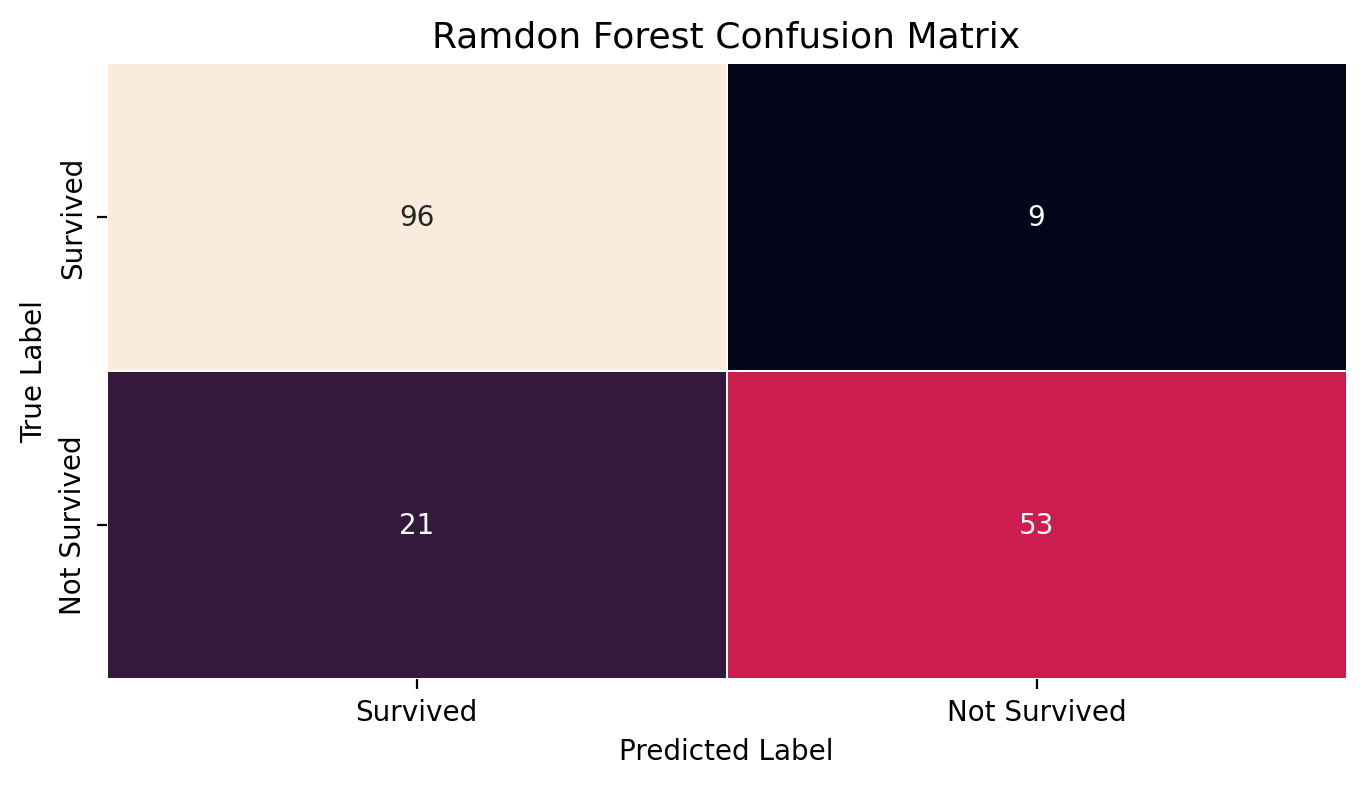

In [175]:
#混淆矩阵
confusion_mtx = confusion_matrix(y_test,rf_y_pred_label)
f,ax = plt.subplots(figsize = (8,4),dpi=200)
sns.heatmap(confusion_mtx, annot=True, linewidths=0.1, fmt='.0f', ax=ax,cbar=False,
xticklabels=label_name, yticklabels=label_name)

plt.xlabel("Predicted Label",fontsize=10)
plt.ylabel("True Label",fontsize=10)
plt.title("Ramdon Forest Confusion Matrix",fontsize=13)
plt.show()


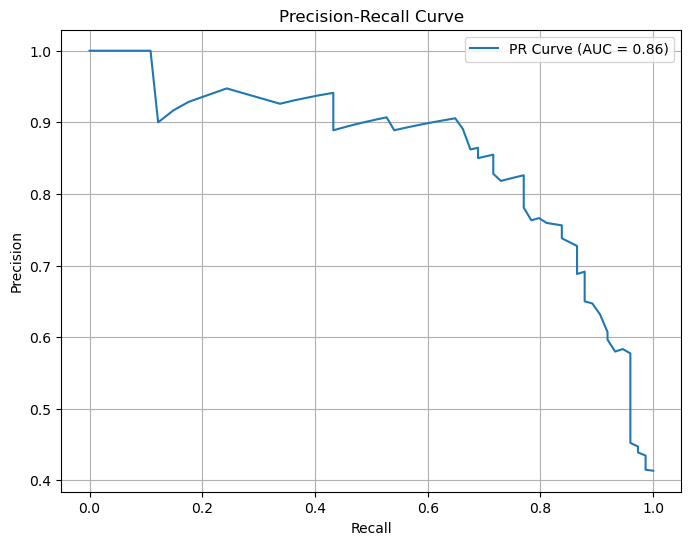

PR AUC: 0.8558
Average Precision Score: 0.7903


In [208]:
draw_pr_auc(y_test,rf_y_pred_prob)

#  GBT


In [214]:

# 创建分类模型
xgb_model = xgb.XGBClassifier(
    objective="binary:logistic",  # 二分类任务
    n_estimators=400,
    use_label_encoder=False,
    eval_metric="logloss"  # 避免 warning
)

# 拟合模型
xgb_model.fit(X_train, y_train)

# 预测结果（预测的是生还概率）
xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]  # 第1列是生还的概率
xgb_y_pred = xgb_model.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_y_pred)
xgb_recall = recall_score(y_test, xgb_y_pred)
xgb_precision = precision_score(y_test, xgb_y_pred)

# 模型评估
print(f"GBT Accuracy:  {xgb_acc:.4f}")
print(f"GBT Recall:    {xgb_recall:.4f}")
print(f"GBT Precision: {xgb_precision:.4f}")

GBT Accuracy:  0.7765
GBT Recall:    0.6486
GBT Precision: 0.7742


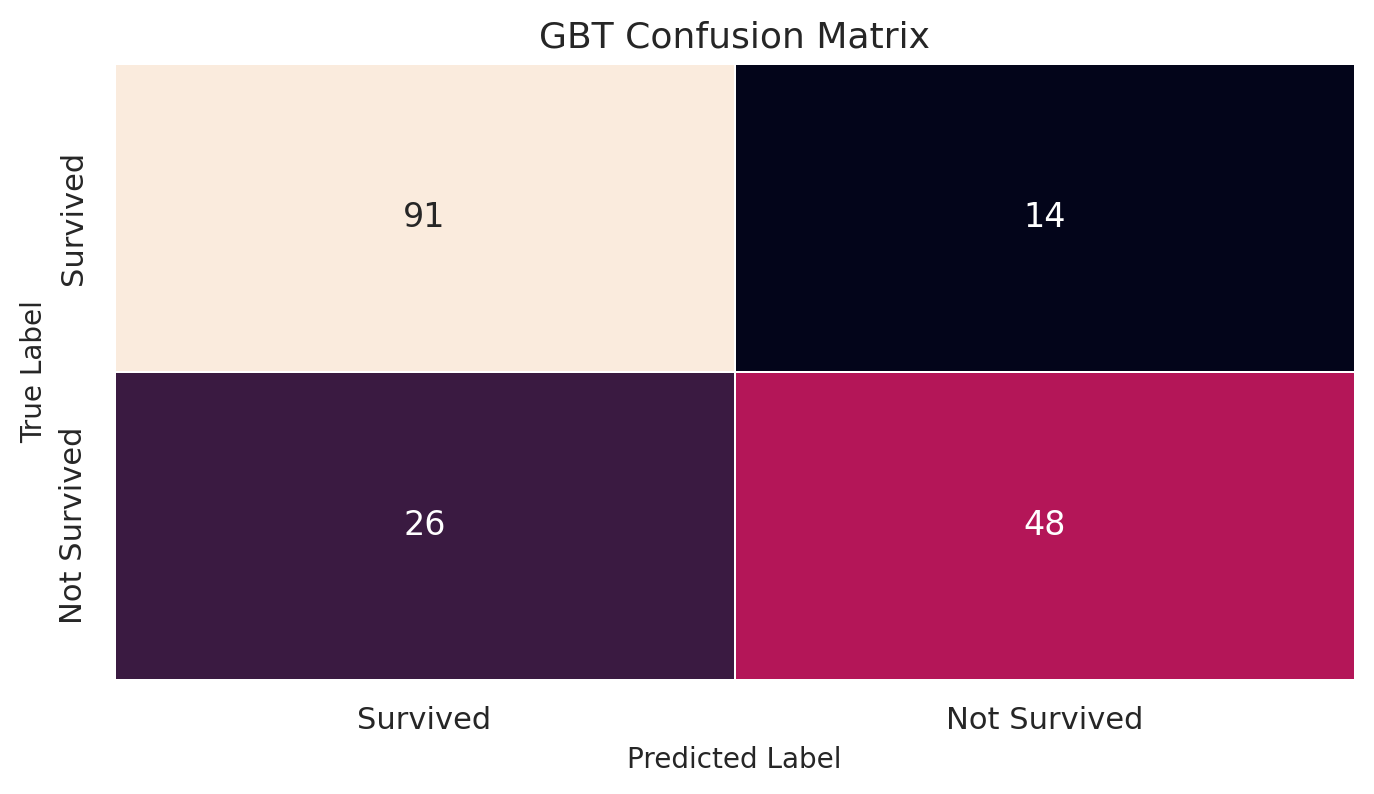

In [215]:
#混淆矩阵
confusion_mtx = confusion_matrix(y_test, xgb_y_pred)
f,ax = plt.subplots(figsize = (8,4),dpi=200)
sns.heatmap(confusion_mtx, annot=True, linewidths=0.1, fmt='.0f', ax=ax,cbar=False,
xticklabels=label_name, yticklabels=label_name)

plt.xlabel("Predicted Label",fontsize=10)
plt.ylabel("True Label",fontsize=10)
plt.title("GBT Confusion Matrix",fontsize=13)
plt.show()


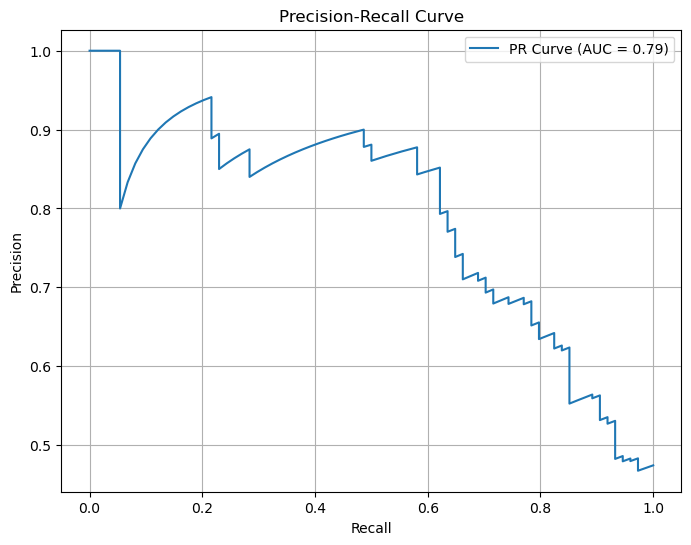

PR AUC: 0.7878
Average Precision Score: 0.7903


In [206]:
draw_pr_auc(y_test,xgb_pred_proba)

                  Importance
Feature                     
Sex_hash            0.303220
Pclass              0.198873
Parch               0.100453
SibSp               0.090994
Cabin_hash          0.060682
Embarked_hash       0.046550
Ticket_item_hash    0.045448
Age                 0.033317
Fare                0.028532
Ticket_hash         0.026346
Name_hash           0.023055
PassengerId         0.022362
Ticket_number       0.020170


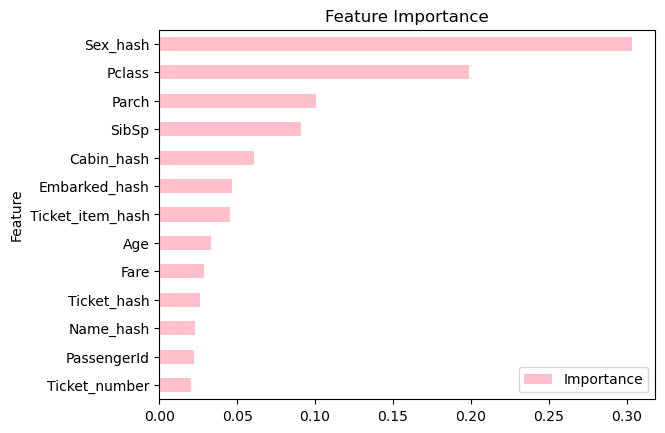

In [211]:

xgb_reg_model = xgb.XGBRegressor(objective="reg:squarederror", n_estimators=400)
xgb_model.fit(X_train, y_train)

importance = xgb_model.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
importance_df = importance_df.set_index('Feature') 
print(importance_df)


importance_df.sort_values("Importance").plot(kind="barh", color = 'pink')
plt.title('Feature Importance')
plt.show()

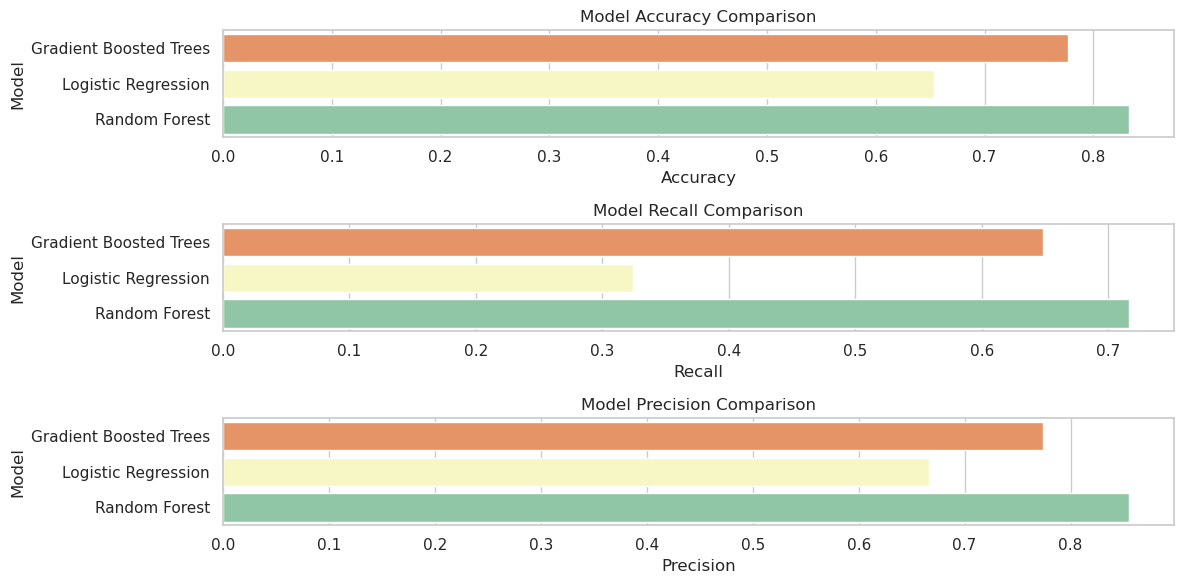

In [217]:
# 设置绘图风格
sns.set(style="whitegrid")

# 模型名称
models = ['Gradient Boosted Trees', 'Logistic Regression', 'Random Forest']

# 模型性能指标


accuracy = [xgb_acc,  lr_acc, rf_acc]  
recall = [xgb_recall, lr_recall, rf_recall]     
precision = [xgb_precision, lr_precision, rf_precision] 

# 创建DataFrame
df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy,
    'Recall': recall,
    'Precision': precision
})


# 创建子图
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 6))

# 准确率图
sns.barplot(x='Accuracy', y='Model', data=df, ax=axes[0], palette='Spectral')
axes[0].set_title('Model Accuracy Comparison')

# recall图
sns.barplot(x='Recall', y='Model', data=df, ax=axes[1], palette='Spectral')
axes[1].set_title('Model Recall Comparison')

# precision图
sns.barplot(x='Precision', y='Model', data=df, ax=axes[2], palette='Spectral')
axes[2].set_title('Model Precision Comparison')

# 调整布局
plt.tight_layout()